### Red wine dataset classification, dataset optimization attempts, version 1

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# pip install xgboost
from xgboost import XGBClassifier


In [147]:
df = pd.read_csv("winequality-red.csv")

### Optimizations - SMOTE

Original class distribution:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


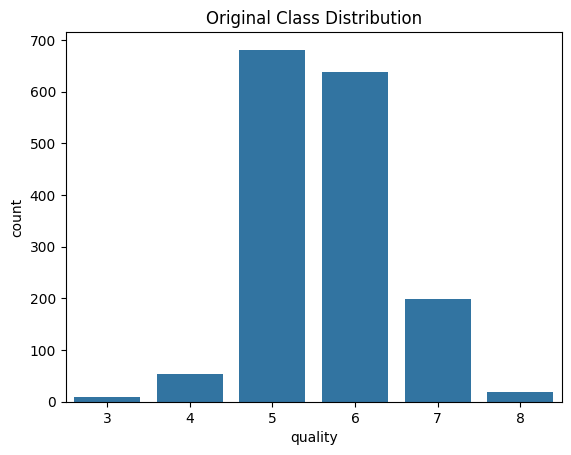

New class distribution after SMOTE:
quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64


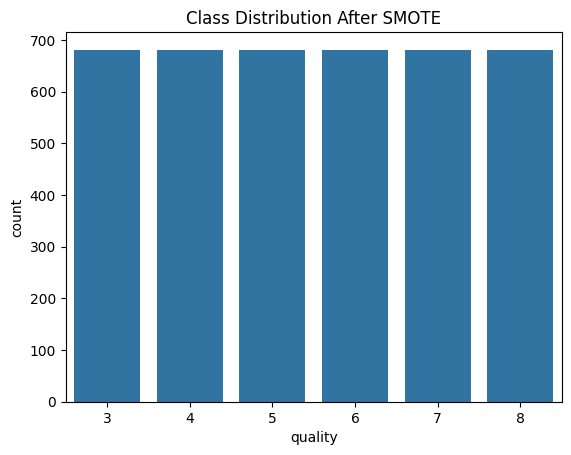

In [148]:
# Separate features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Apply SMOTE to the dataset
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine resampled features and target into a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

# Display original class distribution
print("Original class distribution:")
print(df['quality'].value_counts())

# Visualize original distribution
sns.countplot(x='quality', data=df)
plt.title('Original Class Distribution')
plt.show()

# Display new class distribution
print("New class distribution after SMOTE:")
print(df_resampled['quality'].value_counts())

# Visualize new distribution
sns.countplot(x='quality', data=df_resampled)
plt.title('Class Distribution After SMOTE')
plt.show()


# use the resampled DataFrame
df = df_resampled

### In order to to get our metrics to be more realistic, let's reserve the real wines as test dataset in the future

In [149]:
# TODO: reserve the original real wines as the testing dataset after generating the synthetic ones

### Since this dataset suffers from overlapping between qualities 5 and 6 (middle range wines), TomekLinks is probably a good idea

In [150]:
# initialize TomekLinks
# TomekLinks is used to reduce data overlap throughout the dataset
# howewer, we can't really configure its parameters
tomek = TomekLinks()

# X/y -split
X = df.drop("quality", axis=1)
y = df['quality']

# create new resampled versions of X and y
X_resampled, y_resampled = tomek.fit_resample(X, y)

# re-create a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

df = df_resampled

### Add some slight outlier removal (Isolation Forest)

In [151]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.015) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

# use the inliers as the new DataFrame
df = inliers

Inliers: 3856
Outliers: 59


### Use clustering to help out the model in differentiating between the qualities (especially with the qualities 5 and 6)

In [152]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3910,8.352517,0.404090,0.379394,1.782323,0.066763,5.469680,12.176773,0.995308,3.328787,0.762477,11.399485,8
3911,10.189860,0.508986,0.584216,3.484329,0.078431,6.504609,17.486173,0.996691,3.214954,0.690000,12.945852,8
3912,6.964958,0.666972,0.202007,1.555109,0.056788,21.306532,83.656952,0.993055,3.380074,0.761059,12.558760,8
3913,9.051585,0.340580,0.435805,2.176122,0.065761,4.058048,14.587073,0.996635,3.187678,0.861939,10.529024,8


### Train/test -split

In [153]:
X = df.drop("quality", axis=1)
y = df['quality']

In [154]:
categories = list(np.unique(df['quality']))


# encode the target from original 3, 4, 5, 6, 7, 8 to 0, 1, 2, 3, 4, 5
le = LabelEncoder()
y = le.fit_transform(y)

# stratify can be used to ensure data balance between train/test -datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)


### XGBoost classifier

In [155]:
# create XGboost model
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(categories),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# fit the model / start training
model.fit(X_train, y_train)

,objective,'multi:softmax'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Metrics

In [156]:
test_predictions = model.predict(X_test)

<Axes: >

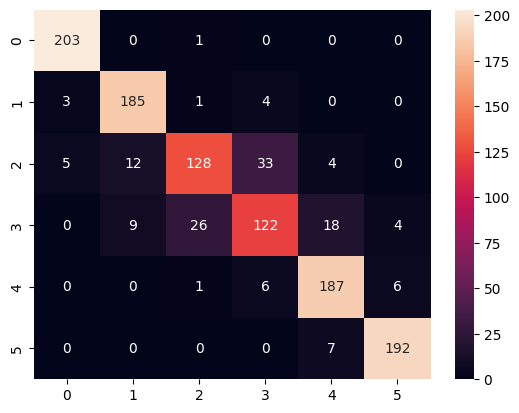

In [157]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g')


In [158]:
print(classification_report(y_test, test_predictions))

acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       204
           1       0.90      0.96      0.93       193
           2       0.82      0.70      0.76       182
           3       0.74      0.68      0.71       179
           4       0.87      0.94      0.90       200
           5       0.95      0.96      0.96       199

    accuracy                           0.88      1157
   macro avg       0.87      0.87      0.87      1157
weighted avg       0.88      0.88      0.88      1157


Model overall accuracy: 87.90%


More than 60% of our data is synthetic, which was generated by SMOTE.

Additionally, 99% of data in certain categories are synthetic.

It might be this result is overly optimistic.

IDEA:

Use the real wines as testing dataset, and use synthetic wines as training dataset.